# 05 - Option strategies

Objectif: construire des strategies d'options vanille (call spread, put spread, butterfly), visualiser leurs payoffs et verifier la decomposition en jambes elementaires.

## Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.market.market_data import MarketData
from src.models.black_scholes import BlackScholesModel
from src.products.option_strategy import OptionStrategy

## Build strategies

In [2]:
call_spread = OptionStrategy.call_spread(
    product_id="CS-1",
    maturity=1.0,
    strike_low=95.0,
    strike_high=105.0,
)

put_spread = OptionStrategy.put_spread(
    product_id="PS-1",
    maturity=1.0,
    strike_low=90.0,
    strike_high=110.0,
)

butterfly = OptionStrategy.butterfly(
    product_id="BF-1",
    maturity=1.0,
    strike_low=90.0,
    strike_mid=100.0,
    strike_high=110.0,
)

strategies = {
    "call_spread": call_spread,
    "put_spread": put_spread,
    "butterfly": butterfly,
}

pd.DataFrame(call_spread.decomposition())

,label,product_id,option_type,strike,quantity
0,long_call_k1,CS-1-C-LONG,call,95.0,1.0
1,short_call_k2,CS-1-C-SHORT,call,105.0,-1.0


## Payoff profiles

In [3]:
spot_grid = np.linspace(60.0, 140.0, 200)

payoff_frame = pd.DataFrame({"spot": spot_grid})
for name, strategy in strategies.items():
    payoff_frame[name] = [strategy.payoff(spot) for spot in spot_grid]

payoff_frame.head()

,spot,call_spread,put_spread,butterfly
0,60.00000,0.0,20.0,0.0
1,60.40201,0.0,20.0,0.0
2,60.80402,0.0,20.0,0.0
3,61.20603,0.0,20.0,0.0
4,61.60804,0.0,20.0,0.0


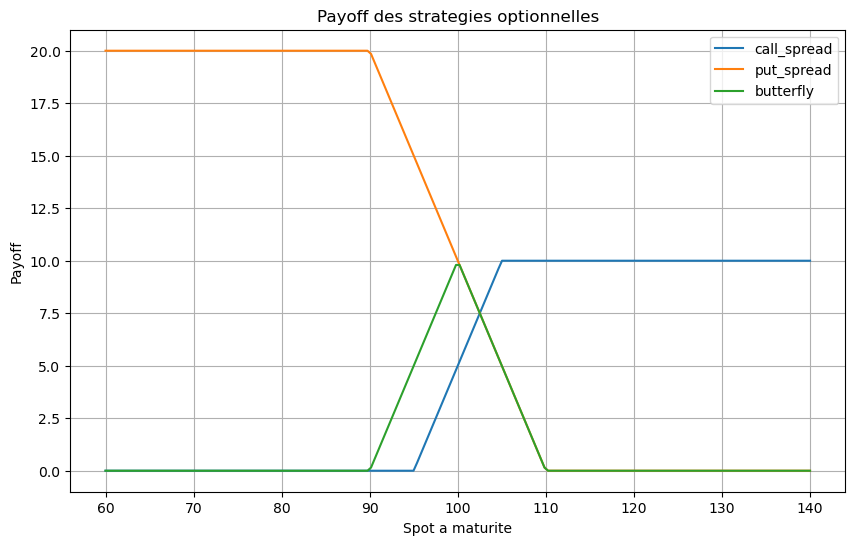

In [4]:
plt.figure(figsize=(10, 6))
for name in ("call_spread", "put_spread", "butterfly"):
    plt.plot(payoff_frame["spot"], payoff_frame[name], label=name)
plt.xlabel("Spot a maturite")
plt.ylabel("Payoff")
plt.title("Payoff des strategies optionnelles")
plt.grid(True)
plt.legend()
plt.show()

## Pricing and decomposition check

In [5]:
bs_model = BlackScholesModel()
market_data = MarketData(spot=100.0, rate=0.03, volatility=0.20, dividend_yield=0.0)

rows = []
for name, strategy in strategies.items():
    direct_price = strategy.price(bs_model, market_data)
    leg_sum_price = sum(
        leg.quantity * bs_model.price(leg.product, market_data)
        for leg in strategy.legs
    ) * strategy.notional
    rows.append(
        {
            "strategy": name,
            "price": direct_price,
            "sum_of_legs": leg_sum_price,
            "difference": direct_price - leg_sum_price,
        }
    )

pd.DataFrame(rows)

,strategy,price,sum_of_legs,difference
0,call_spread,5.051637,5.051637,0.0
1,put_spread,9.273081,9.273081,0.0
2,butterfly,1.895819,1.895819,0.0
